In [2]:
import torch
import string
import unicodedata
import torch.nn as nn
import torch.nn.functional as F
from __future__ import unicode_literals,print_function,division
import re
from io import open 
import glob
import os
import time
import math
import random
import numpy as np
from torch import optim
from torch.utils.data import Dataset,TensorDataset,DataLoader,RandomSampler,random_split
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
device=torch.device('cpu')
torch.set_default_device(device)
torch.get_default_device
ALLOWED_CHARACTERS = string.ascii_letters + " .,;'_"
N_LETTERS = len(ALLOWED_CHARACTERS)

### Helper Functions

def unicode_to_ascii(input_string):
    """
    Normalizes unicode strings to plain ASCII and filters allowed characters.
    """
    return ''.join(
        char for char in unicodedata.normalize('NFD', input_string)
        if unicodedata.category(char) != 'Mn'
        and char in ALLOWED_CHARACTERS
    )

def letter_to_index(letter):
    """
    Maps a single character to its integer index in ALLOWED_CHARACTERS.
    """
    if letter not in ALLOWED_CHARACTERS:
        return ALLOWED_CHARACTERS.find("_")
    return ALLOWED_CHARACTERS.find(letter)

def line_to_tensor(line):
    """
    Converts a string (line) into a One-Hot encoded tensor of shape:
    (line_length, 1, n_letters)
    """
    tensor = torch.zeros(len(line), 1, N_LETTERS)
    for index, letter in enumerate(line):
        tensor[index][0][letter_to_index(letter)] = 1
    return tensor

example_input = 'Ślusàrski'
print(f"Original: {example_input} -> ASCII: {unicode_to_ascii(example_input)}")

Original: Ślusàrski -> ASCII: Slusarski


In [3]:
class NamesDataset(Dataset):
    def __init__(self, data_directory):
        self.data_directory = data_directory
        self.names = []
        self.name_tensors = []
        self.labels = []
        self.label_tensors = []
        file_paths = glob.glob(os.path.join(data_directory, '*.txt'))
        self.unique_labels = [os.path.splitext(os.path.basename(fp))[0] for fp in file_paths]
        
        for file_path in file_paths:
            category = os.path.splitext(os.path.basename(file_path))[0]
            lines = open(file_path, encoding='utf-8').read().strip().split('\n')
            for name in lines:
                self.names.append(name)
                self.labels.append(category)
                self.name_tensors.append(line_to_tensor(name))
    
        for label in self.labels:
            label_index = self.unique_labels.index(label)
            self.label_tensors.append(torch.tensor([label_index], dtype=torch.long))

    def __len__(self):
        return len(self.names)

    def __getitem__(self, idx):
        return (
            self.label_tensors[idx], 
            self.name_tensors[idx], 
            self.labels[idx], 
            self.names[idx]
        )

### Data Initialization
data_path = "Datasets/data/names"
all_data = NamesDataset(data_path)

print(f"Loaded {len(all_data)} items of data.")

### Train/Test Split 
train_data, test_data = random_split(
    all_data, 
    [0.85, 0.15], 
    generator=torch.Generator(device=device).manual_seed(2024)
)
print(f"Training set: {len(train_data)} | Test set: {len(test_data)}")

Loaded 20074 items of data.
Training set: 17063 | Test set: 3011


In [4]:
class CharacterRNN(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(CharacterRNN, self).__init__()
        self.hidden_size = hidden_size
        self.rnn = nn.RNN(input_size, hidden_size)
        self.fc_output = nn.Linear(hidden_size, output_size)
        self.softmax = nn.LogSoftmax(dim=1)

    def forward(self, line_tensor):
        rnn_output, hidden = self.rnn(line_tensor)
        output = self.fc_output(hidden[0])
        output = self.softmax(output)
        return output

## Model Initialization
n_hidden = 128
n_categories = len(all_data.unique_labels)
rnn = CharacterRNN(N_LETTERS, n_hidden, n_categories)
rnn.to(device)
print(rnn)

CharacterRNN(
  (rnn): RNN(58, 128)
  (fc_output): Linear(in_features=128, out_features=18, bias=True)
  (softmax): LogSoftmax(dim=1)
)


In [ ]:
def label_from_output(output, all_categories):
    """
    Decodes the network output to get the predicted category name and index.
    """
    top_n, top_i = output.topk(1)
    category_index = top_i[0].item()
    return all_categories[category_index], category_index

sample_input = line_to_tensor('Albert')
sample_output = rnn(sample_input)
print(sample_output, label_from_output(sample_output, all_data.unique_labels))

def train_model(model, train_set, epochs=10, batch_size=64, report_every=50, learning_rate=0.2, criterion=nn.NLLLoss()):
    """
    Handles the training process using SGD and gradient clipping.
    """
    current_loss = 0
    all_losses = []
    model.train()
    optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)
    
    start_time = time.time()
    print(f"Training on dataset with n = {len(train_set)}")

    for epoch in range(1, epochs + 1):
        model.zero_grad()
        indices = list(range(len(train_set)))
        random.shuffle(indices)
        batches = np.array_split(indices, max(1, len(indices) // batch_size))
        for batch in batches:
            batch_loss = 0
            for i in batch:
                label_tensor, name_tensor, label, name = train_set[i]
                output = model(name_tensor)
                loss = criterion(output, label_tensor)
                batch_loss += loss
            batch_loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=3)
            optimizer.step()
            optimizer.zero_grad()
            current_loss += batch_loss.item() / len(batches)
        all_losses.append(current_loss / len(batches))
        if epoch % report_every == 0:
            percent_complete = (epoch / epochs) * 100
            print(f"Epoch {epoch} ({percent_complete:.0f}%): Average Batch Loss = {all_losses[-1]:.4f}") 
        current_loss = 0
    return all_losses

def evaluate_model(model, test_set, categories):
    """
    Evaluates the model and displays a normalized confusion matrix.
    """
    n_categories = len(categories)
    confusion = torch.zeros(n_categories, n_categories)
    model.eval()
    with torch.no_grad():
        for i in range(len(test_set)):
            label_tensor, name_tensor, label, name = test_set[i]
            output = model(name_tensor)
            guess, guess_index = label_from_output(output, categories)
            actual_index = categories.index(label)
            confusion[actual_index][guess_index] += 1

    for i in range(n_categories):
        row_sum = confusion[i].sum()
        if row_sum > 0:
            confusion[i] = confusion[i] / row_sum
            
    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111)
    cax = ax.matshow(confusion.cpu().numpy())
    fig.colorbar(cax)
    ax.set_xticks(np.arange(n_categories))
    ax.set_xticklabels(categories, rotation=90)
    ax.set_yticks(np.arange(n_categories))
    ax.set_yticklabels(categories)
    ax.xaxis.set_major_locator(ticker.MultipleLocator(1))
    ax.yaxis.set_major_locator(ticker.MultipleLocator(1))
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

tensor([[-2.7393, -2.8874, -3.0055, -2.8955, -2.9984, -2.9687, -2.9454, -2.8637,
         -2.8392, -2.9083, -2.8341, -2.8483, -2.8361, -2.8747, -2.9913, -2.8475,
         -2.8707, -2.9135]], grad_fn=<LogSoftmaxBackward0>) ('Arabic', 0)


Training on dataset with n = 17063
Epoch 5 (19%): Average Batch Loss = 0.2093
Epoch 10 (37%): Average Batch Loss = 0.1671
Epoch 15 (56%): Average Batch Loss = 0.1395
Epoch 20 (74%): Average Batch Loss = 0.1196
Epoch 25 (93%): Average Batch Loss = 0.1066
Training took: 1463.16s


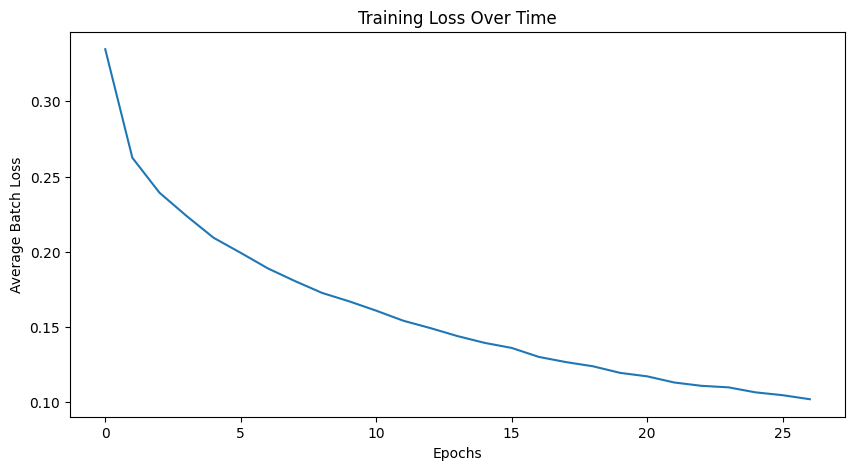

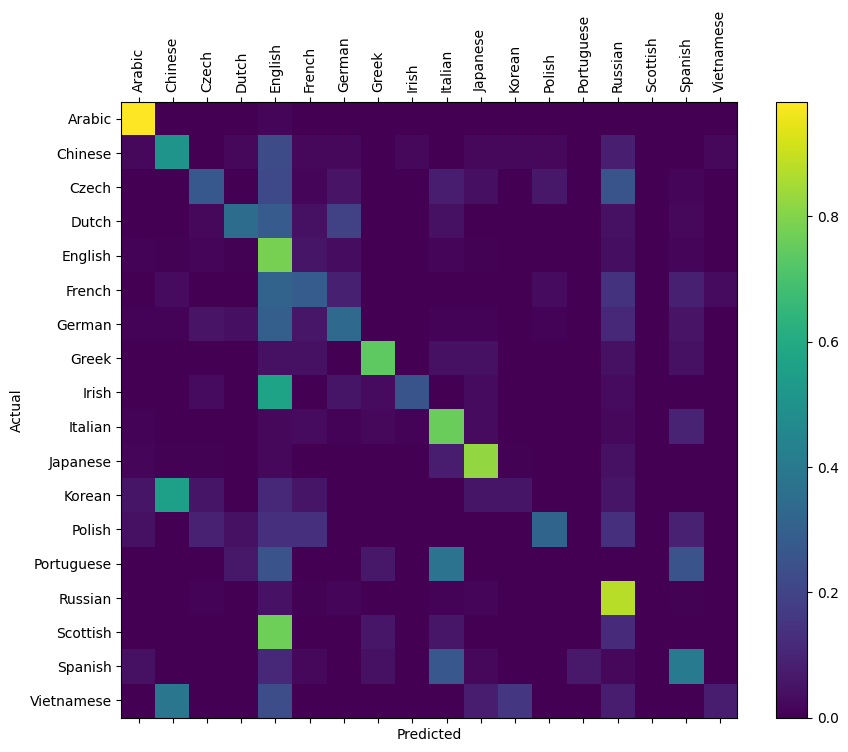

In [6]:
### Model Training Execution
start_time = time.time()

all_losses = train_model(
    model=rnn, 
    train_set=train_data, 
    epochs=27, 
    learning_rate=0.15, 
    report_every=5
)
end_time = time.time()
print(f"Training took: {end_time - start_time:.2f}s")

### Visualization
plt.figure(figsize=(10, 5))
plt.title("Training Loss Over Time")
plt.plot(all_losses)
plt.xlabel("Epochs")
plt.ylabel("Average Batch Loss")
plt.show()

### Evaluation
evaluate_model(
    model=rnn, 
    test_set=test_data, 
    categories=all_data.unique_labels
)

In [10]:
### Configuration
N_LETTERS_EXTENDED = len(ALLOWED_CHARACTERS) + 1

def find_files(path):
    """
    Returns a list of file paths matching the given pattern.
    """
    return glob.glob(path)

def read_lines(filename):
    """
    Reads a file and converts each line from Unicode to ASCII.
    """
    with open(filename, encoding='utf-8') as file:
        return [unicode_to_ascii(line.strip()) for line in file]

### Data Loading 
category_lines = {}
all_categories = []
for filename in find_files('Datasets/data/names/*.txt'):
    category = os.path.splitext(os.path.basename(filename))[0]
    all_categories.append(category)
    
    lines = read_lines(filename)
    category_lines[category] = lines
n_categories = len(all_categories)

### Validation & Output
if n_categories == 0:
    raise RuntimeError(
        "Data not found. Please ensure the 'Datasets/data/names/' directory exists and contains .txt files."
    )

print(f"Number of categories: {n_categories}")
print(f"Categories: {all_categories}")
name = "O'Néàl"
print(f"Sample Conversion: {name} -> {unicode_to_ascii(name)}")

Number of categories: 18
Categories: ['Arabic', 'Chinese', 'Czech', 'Dutch', 'English', 'French', 'German', 'Greek', 'Irish', 'Italian', 'Japanese', 'Korean', 'Polish', 'Portuguese', 'Russian', 'Scottish', 'Spanish', 'Vietnamese']
Sample Conversion: O'Néàl -> O'Neal


In [11]:
class CharacterGeneratorRNN(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(CharacterGeneratorRNN, self).__init__()
        self.hidden_size = hidden_size
        self.input_to_hidden = nn.Linear(n_categories + input_size + hidden_size, hidden_size)
        self.input_to_output = nn.Linear(n_categories + input_size + hidden_size, output_size)
        self.output_to_output = nn.Linear(hidden_size + output_size, output_size)
        self.dropout = nn.Dropout(0.1)
        self.softmax = nn.LogSoftmax(dim=1)

    def forward(self, category_tensor, input_tensor, hidden_tensor):
        """
        Processes a single step in the sequence.
        """
        combined_input = torch.cat((category_tensor, input_tensor, hidden_tensor), 1)
        hidden_state = self.input_to_hidden(combined_input)
        raw_output = self.input_to_output(combined_input)
        combined_output = torch.cat((hidden_state, raw_output), 1)
        final_output = self.output_to_output(combined_output)
        final_output = self.dropout(final_output)
        final_output = self.softmax(final_output)
        
        return final_output, hidden_state

    def init_hidden(self):
        """
        Initializes a fresh hidden state of zeros.
        """
        return torch.zeros(1, self.hidden_size)

In [12]:
## Random Sampling Functions

def random_choice(input_list):
    """Returns a random element from the list."""
    return input_list[random.randint(0, len(input_list) - 1)]

def random_training_pair():
    """Selects a random category and a random name from within that category."""
    category = random_choice(all_categories)
    line = random_choice(category_lines[category])
    return category, line

## Tensor Conversion Functions

def category_to_tensor(category):
    """Creates a One-Hot tensor for the given category."""
    index = all_categories.index(category)
    tensor = torch.zeros(1, n_categories)
    tensor[0][index] = 1
    return tensor

def input_to_tensor(line):
    """Creates a One-Hot encoded tensor for the input string sequence."""
    tensor = torch.zeros(len(line), 1, N_LETTERS_EXTENDED)
    for i in range(len(line)):
        char = line[i]
        tensor[i][0][ALLOWED_CHARACTERS.find(char)] = 1
    return tensor

def target_to_tensor(line):
    """
    Creates a LongTensor of character indices for the target.
    Shifted by one character (next character prediction) and ends with EOS.
    """
    char_indices = [ALLOWED_CHARACTERS.find(line[i]) for i in range(1, len(line))]
    char_indices.append(N_LETTERS_EXTENDED - 1)  # EOS (End of Sentence) index
    return torch.LongTensor(char_indices)

def random_training_example():
    """Generates a full set of tensors for a single random training instance."""
    category, line = random_training_pair()
    category_tensor = category_to_tensor(category)
    input_line_tensor = input_to_tensor(line)
    target_line_tensor = target_to_tensor(line)
    
    return category_tensor, input_line_tensor, target_line_tensor

In [13]:
criterion = nn.NLLLoss()
learning_rate = 0.0005
hidden_size = 128

### Training & Utility Functions 

def train_step(category_tensor, input_line_tensor, target_line_tensor):
    """
    Performs a single training step (forward pass, backward pass, and parameter update).
    """
    target_line_tensor.unsqueeze_(-1)
    hidden = rnn_generator.init_hidden()
    
    rnn_generator.zero_grad()
    total_loss = torch.zeros(1)
    
    # Process sequence character by character
    for i in range(input_line_tensor.size(0)):
        output, hidden = rnn_generator(category_tensor, input_line_tensor[i], hidden)
        loss = criterion(output, target_line_tensor[i])
        total_loss += loss
        
    total_loss.backward()
    
    for p in rnn_generator.parameters():
        p.data.add_(p.grad.data, alpha=-learning_rate)
        
    average_loss = total_loss.item() / input_line_tensor.size(0)
    return output, average_loss

def time_since(since):
    """
    Calculates elapsed time from a starting point in minutes and seconds.
    """
    now = time.time()
    seconds = now - since
    minutes = math.floor(seconds / 60)
    seconds -= minutes * 60
    return f'{minutes}m {seconds:.0f}s'

# Initialize the Model
rnn_generator = CharacterGeneratorRNN(N_LETTERS_EXTENDED, hidden_size, N_LETTERS_EXTENDED)

0m 47s (5000 5%) Loss: 3.5935
1m 32s (10000 10%) Loss: 2.5421
2m 18s (15000 15%) Loss: 2.5424
3m 3s (20000 20%) Loss: 2.1795
3m 42s (25000 25%) Loss: 2.3566
4m 21s (30000 30%) Loss: 3.6534
4m 53s (35000 35%) Loss: 2.5693
5m 25s (40000 40%) Loss: 1.9770
5m 58s (45000 45%) Loss: 2.7397
6m 48s (50000 50%) Loss: 1.7415
7m 41s (55000 55%) Loss: 1.9961
8m 34s (60000 60%) Loss: 2.0979
9m 15s (65000 65%) Loss: 1.8854
9m 60s (70000 70%) Loss: 2.0710
10m 50s (75000 75%) Loss: 2.3820
11m 25s (80000 80%) Loss: 1.6701
12m 4s (85000 85%) Loss: 2.5087
12m 47s (90000 90%) Loss: 2.2001
13m 27s (95000 95%) Loss: 0.9889
14m 14s (100000 100%) Loss: 1.7008


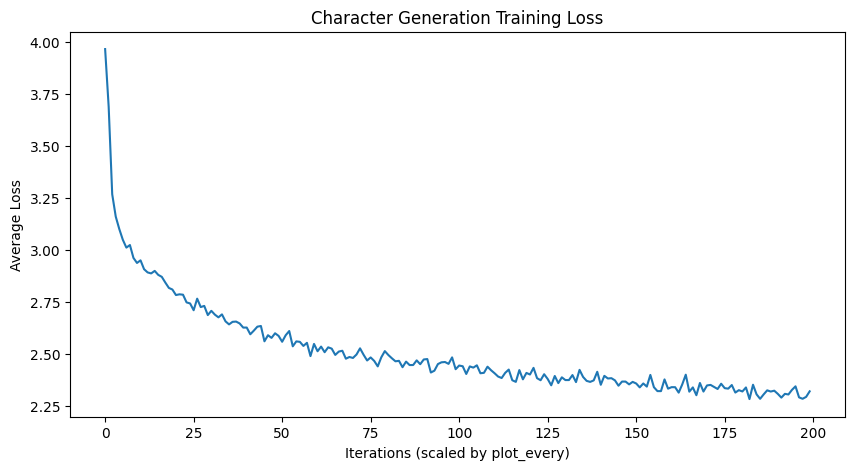

In [14]:
n_iterations = 100000
print_every = 5000
plot_every = 500
all_losses = []
total_loss = 0

start_time = time.time()

### Training Loop
for iteration in range(1, n_iterations + 1):
    category_tensor, input_line_tensor, target_line_tensor = random_training_example()
    output, loss = train_step(category_tensor, input_line_tensor, target_line_tensor)
    total_loss += loss
    if iteration % print_every == 0:
        progress_percent = (iteration / n_iterations) * 100
        print(f'{time_since(start_time)} ({iteration} {progress_percent:.0f}%) Loss: {loss:.4f}')
    if iteration % plot_every == 0:
        all_losses.append(total_loss / plot_every)
        total_loss = 0

### Visualization
plt.figure(figsize=(10, 5))
plt.title("Character Generation Training Loss")
plt.plot(all_losses)
plt.xlabel("Iterations (scaled by plot_every)")
plt.ylabel("Average Loss")
plt.show()

In [15]:
MAX_LENGTH = 20
def sample(category, start_letter='A'):
    """
    Generates a name by predicting one character at a time 
    until the EOS token is reached or MAX_LENGTH is hit.
    """
    with torch.no_grad():
        category_tensor = category_to_tensor(category)
        input_char_tensor = input_to_tensor(start_letter)
        hidden = rnn_generator.init_hidden()
        output_name = start_letter

        for _ in range(MAX_LENGTH):
            output, hidden = rnn_generator(category_tensor, input_char_tensor[0], hidden)
            top_v, top_i = output.topk(1)
            char_index = top_i[0][0].item()
            if char_index == N_LETTERS_EXTENDED - 1:
                break
            else:
                letter = ALLOWED_CHARACTERS[char_index]
                output_name += letter
            input_char_tensor = input_to_tensor(letter)

        return f"{category}: {output_name}"

def samples(category, start_letters='ABC'):
    """
    Helper to print multiple samples for a given category.
    """
    for start_letter in start_letters:
        print(sample(category, start_letter))

samples('Russian', 'RUS')
samples('German', 'GER')
samples('Spanish', 'SPA')
samples('Chinese', 'CHI')

Russian: Rovekov
Russian: Uakilov
Russian: Shivakov
German: Geller
German: Eeller
German: Roures
Spanish: Salla
Spanish: Parea
Spanish: Alana
Chinese: Chan
Chinese: Han
Chinese: Iun


In [16]:
SOS_TOKEN = 0  # Start Of Sentence
EOS_TOKEN = 1  # End Of Sentence

class LanguageVocabulary:
    def __init__(self, name):
        self.name = name
        self.word2index = {}
        self.word2count = {}
        self.index2word = {0: "SOS", 1: "EOS"}
        self.n_words = 2  # Count SOS and EOS initially

    def add_sentence(self, sentence):
        """
        Splits a sentence by whitespace and adds each word to the vocabulary.
        """
        for word in sentence.split(' '):
            self.add_word(word)

    def add_word(self, word):
        """
        Adds a single word to the vocabulary and updates mapping dictionaries.
        """
        if word not in self.word2index:
            self.word2index[word] = self.n_words
            self.word2count[word] = 1
            self.index2word[self.n_words] = word
            self.n_words += 1
        else:
            self.word2count[word] += 1

In [17]:
### Text Normalization

def unicode_to_ascii(text):
    """
    Converts Unicode characters to plain ASCII by removing diacritics.
    """
    return ''.join(
        char for char in unicodedata.normalize('NFD', text)
        if unicodedata.category(char) != 'Mn'
    )

def normalize_string(text):
    """
    Lowercases, trims, and cleans the string of non-alphabetic characters.
    """
    text = unicode_to_ascii(text.lower().strip())
    # Separate punctuation from words with a space
    text = re.sub(r"([.!?])", r" \1", text)
    # Remove any character that is not a letter or basic punctuation
    text = re.sub(r"[^a-zA-Z.!?]+", r" ", text)
    return text.strip()

### Data Loading 

def read_languages(lang1, lang2, reverse=False):
    """
    Reads the dataset file and returns Language objects and sentence pairs.
    """
    print("Reading lines...")
    path = f'Datasets/data1/{lang1}-{lang2}.txt'
    lines = open(path, encoding='utf-8').read().strip().split('\n')
    pairs = [[normalize_string(s) for s in line.split('\t')] for line in lines]
    if reverse:
        pairs = [list(reversed(p)) for p in pairs]
        input_lang = LanguageVocabulary(lang2)
        output_lang = LanguageVocabulary(lang1)
    else:
        input_lang = LanguageVocabulary(lang1)
        output_lang = LanguageVocabulary(lang2)  
    return input_lang, output_lang, pairs

In [18]:
MAX_LENGTH = 10
ENGLISH_PREFIXES = (
    "i am ", "i m ",
    "he is ", "he s ",
    "she is ", "she s ",
    "you are ", "you re ",
    "we are ", "we re ",
    "they are ", "they re "
)

### Filtering Functions

def filter_pair(pair):
    """
    Returns True if both sentences are under MAX_LENGTH and 
    the target sentence starts with one of the predefined prefixes.
    """
    return len(pair[0].split(' ')) < MAX_LENGTH and \
           len(pair[1].split(' ')) < MAX_LENGTH and \
           pair[1].startswith(ENGLISH_PREFIXES)

def filter_pairs(pairs):
    """
    Filters a list of sentence pairs using the filter_pair criteria.
    """
    return [pair for pair in pairs if filter_pair(pair)]

### Data Preparation Pipeline

def prepare_data(lang1, lang2, reverse=False):
    """
    Full pipeline: Reads languages, filters pairs, and populates vocabularies.
    """
    input_lang, output_lang, pairs = read_languages(lang1, lang2, reverse)
    print(f"Read {len(pairs)} sentence pairs")
    
    pairs = filter_pairs(pairs)
    print(f"Trimmed to {len(pairs)} sentence pairs")
    
    print("Counting words...")
    for pair in pairs:
        input_lang.add_sentence(pair[0])
        output_lang.add_sentence(pair[1])
        
    print("Counted words:")
    print(f"{input_lang.name}: {input_lang.n_words}")
    print(f"{output_lang.name}: {output_lang.n_words}")
    
    return input_lang, output_lang, pairs

input_lang, output_lang, pairs = prepare_data('eng', 'fra', reverse=True)
print(f"Random sample: {random.choice(pairs)}")

Reading lines...
Read 135842 sentence pairs
Trimmed to 10522 sentence pairs
Counting words...
Counted words:
fra: 4341
eng: 2802
Random sample: ['ils ne sont pas morts .', 'they re not dead .']


In [19]:
class EncoderRNN(nn.Module):
    def __init__(self, input_size, hidden_size, dropout_p=0.1):
        super(EncoderRNN, self).__init__()
        self.hidden_size = hidden_size

        self.embedding = nn.Embedding(input_size, hidden_size)
        self.gru = nn.GRU(hidden_size, hidden_size, batch_first=True)
        self.dropout = nn.Dropout(dropout_p)

    def forward(self, input_tensor):
        embedded = self.dropout(self.embedding(input_tensor))
        output, hidden = self.gru(embedded)
        return output, hidden

class DecoderRNN(nn.Module):
    def __init__(self, hidden_size, output_size):
        super(DecoderRNN, self).__init__()
        self.embedding = nn.Embedding(output_size, hidden_size)
        self.gru = nn.GRU(hidden_size, hidden_size, batch_first=True)
        self.out = nn.Linear(hidden_size, output_size)

    def forward(self, encoder_outputs, encoder_hidden, target_tensor=None):
        batch_size = encoder_outputs.size(0)
        # Initialize decoder input with the SOS_TOKEN
        decoder_input = torch.empty(batch_size, 1, dtype=torch.long, device=device).fill_(SOS_TOKEN)
        decoder_hidden = encoder_hidden
        decoder_outputs = []

        for i in range(MAX_LENGTH):
            decoder_output, decoder_hidden = self.forward_step(decoder_input, decoder_hidden)
            decoder_outputs.append(decoder_output)

            if target_tensor is not None:
                # Teacher forcing: Feed the target as the next input
                decoder_input = target_tensor[:, i].unsqueeze(1)
            else:
                # Without teacher forcing: use its own predictions as the next input
                _, topi = decoder_output.topk(1)
                decoder_input = topi.squeeze(-1).detach()

        decoder_outputs = torch.cat(decoder_outputs, dim=1)
        decoder_outputs = F.log_softmax(decoder_outputs, dim=-1)
        
        return decoder_outputs, decoder_hidden, None # None kept for consistency with Attention models

    def forward_step(self, input_tensor, hidden_tensor):
        embedded = F.relu(self.embedding(input_tensor))
        output, hidden = self.gru(embedded, hidden_tensor)
        output = self.out(output)
        return output, hidden

In [20]:
class BahdanauAttention(nn.Module):
    def __init__(self, hidden_size):
        super(BahdanauAttention, self).__init__()
        self.W_query = nn.Linear(hidden_size, hidden_size)
        self.U_key = nn.Linear(hidden_size, hidden_size)
        self.V_align = nn.Linear(hidden_size, 1)

    def forward(self, query, keys):
        scores = self.V_align(torch.tanh(self.W_query(query) + self.U_key(keys)))
        scores = scores.squeeze(2).unsqueeze(1)
        weights = F.softmax(scores, dim=-1)
        context = torch.bmm(weights, keys)
        return context, weights

class AttentionDecoder(nn.Module):
    def __init__(self, hidden_size, output_size, dropout_p=0.1):
        super(AttentionDecoder, self).__init__()
        self.embedding = nn.Embedding(output_size, hidden_size)
        self.attention = BahdanauAttention(hidden_size)
        self.gru = nn.GRU(2 * hidden_size, hidden_size, batch_first=True)
        self.out = nn.Linear(hidden_size, output_size)
        self.dropout = nn.Dropout(dropout_p)

    def forward(self, encoder_outputs, encoder_hidden, target_tensor=None):
        batch_size = encoder_outputs.size(0)
        decoder_input = torch.empty(batch_size, 1, dtype=torch.long, device=device).fill_(SOS_TOKEN)
        decoder_hidden = encoder_hidden
        
        decoder_outputs = []
        attention_weights_list = []

        for i in range(MAX_LENGTH):
            output, decoder_hidden, attn_weights = self.forward_step(
                decoder_input, decoder_hidden, encoder_outputs
            )
            decoder_outputs.append(output)
            attention_weights_list.append(attn_weights)

            if target_tensor is not None:
                decoder_input = target_tensor[:, i].unsqueeze(1)
            else:
                _, topi = output.topk(1)
                decoder_input = topi.squeeze(-1).detach()

        decoder_outputs = torch.cat(decoder_outputs, dim=1)
        decoder_outputs = F.log_softmax(decoder_outputs, dim=-1)
        attention_weights_list = torch.cat(attention_weights_list, dim=1)
        return decoder_outputs, decoder_hidden, attention_weights_list

    def forward_step(self, input_tensor, hidden_tensor, encoder_outputs):
        embedded = self.dropout(self.embedding(input_tensor))
        query = hidden_tensor.permute(1, 0, 2)
        context, attn_weights = self.attention(query, encoder_outputs)
        gru_input = torch.cat((embedded, context), dim=2)
        output, hidden_tensor = self.gru(gru_input, hidden_tensor)
        output = self.out(output)
        return output, hidden_tensor, attn_weights

In [30]:
### Data Transformation

def indexes_from_sentence(lang, sentence):
    return [lang.word2index[word] for word in sentence.split(' ')]

def tensor_from_sentence(lang, sentence):
    indices = indexes_from_sentence(lang, sentence)
    indices.append(EOS_TOKEN)
    return torch.tensor(indices, dtype=torch.long, device=device).view(1, -1)

def get_dataloader(batch_size):
    input_lang, output_lang, pairs = prepare_data('eng', 'fra', True)
    n = len(pairs)
    
    input_ids = np.zeros((n, MAX_LENGTH), dtype=np.int32)
    target_ids = np.zeros((n, MAX_LENGTH), dtype=np.int32)

    for idx, (inp, tgt) in enumerate(pairs):
        in_ids = indexes_from_sentence(input_lang, inp)
        tg_ids = indexes_from_sentence(output_lang, tgt)
        in_ids.append(EOS_TOKEN)
        tg_ids.append(EOS_TOKEN)
        input_ids[idx, :len(in_ids)] = in_ids
        target_ids[idx, :len(tg_ids)] = tg_ids

    dataset = TensorDataset(torch.LongTensor(input_ids).to(device),
                            torch.LongTensor(target_ids).to(device))
    sampler = RandomSampler(dataset)
    loader = DataLoader(dataset, sampler=sampler, batch_size=batch_size)
    
    return input_lang, output_lang, loader

### Training Logic 

def train_epoch(dataloader, encoder, decoder, encoder_optimizer, decoder_optimizer, criterion):
    total_loss = 0
    for data in dataloader:
        input_tensor, target_tensor = data
        
        encoder_optimizer.zero_grad()
        decoder_optimizer.zero_grad()

        encoder_outputs, encoder_hidden = encoder(input_tensor)
        decoder_outputs, _, _ = decoder(encoder_outputs, encoder_hidden, target_tensor)

        # Flatten outputs for NLLLoss
        loss = criterion(decoder_outputs.view(-1, decoder_outputs.size(-1)), 
                         target_tensor.view(-1))
        
        loss.backward()
        encoder_optimizer.step()
        decoder_optimizer.step()

        total_loss += loss.item()

    return total_loss / len(dataloader)

def show_plot(points):
    """Visualizes the training loss curve."""
    plt.figure()
    fig, ax = plt.subplots()
    loc = ticker.MultipleLocator(base=0.2)
    ax.yaxis.set_major_locator(loc)
    plt.plot(points)
    plt.show()

def train_model(dataloader, encoder, decoder, epochs, lr=0.001, print_every=100, plot_every=100):
    start = time.time()
    plot_losses = []
    print_loss_total = 0
    plot_loss_total = 0

    encoder_optimizer = optim.Adam(encoder.parameters(), lr=lr)
    decoder_optimizer = optim.Adam(decoder.parameters(), lr=lr)
    criterion = nn.NLLLoss()

    for epoch in range(1, epochs + 1):
        loss = train_epoch(dataloader, encoder, decoder, encoder_optimizer, decoder_optimizer, criterion)
        print_loss_total += loss
        plot_loss_total += loss

        if epoch % print_every == 0:
            print_avg = print_loss_total / print_every
            print_loss_total = 0
            print(f'{time_since(start, epoch/epochs)} ({epoch} {epoch/epochs*100:.0f}%) {print_avg:.4f}')

        if epoch % plot_every == 0:
            plot_avg = plot_loss_total / plot_every
            plot_losses.append(plot_avg)
            plot_loss_total = 0

    show_plot(plot_losses)

### Timing Utilities 

def as_minutes(s):
    """Formats seconds into minutes and seconds string."""
    m = math.floor(s / 60)
    s -= m * 60
    return f'{m}m {s:.0f}s'

def time_since(since, percent):
    """Calculates elapsed and estimated remaining time."""
    now = time.time()
    s = now - since
    es = s / percent  # estimated total time
    rs = es - s      # remaining time
    return f'{as_minutes(s)} (- {as_minutes(rs)})'

### Evaluation & Attention Visualization 

def evaluate(encoder, decoder, sentence, input_lang, output_lang):
    """Translates a single sentence and returns attention weights."""
    with torch.no_grad():
        input_tensor = tensor_from_sentence(input_lang, sentence)
        encoder_outputs, encoder_hidden = encoder(input_tensor)
        decoder_outputs, _, attention_weights = decoder(encoder_outputs, encoder_hidden)

        _, topi = decoder_outputs.topk(1)
        decoded_indices = topi.squeeze()

        decoded_words = []
        for idx in decoded_indices:
            if idx.item() == EOS_TOKEN:
                decoded_words.append('<EOS>')
                break
            decoded_words.append(output_lang.index2word[idx.item()])
            
    return decoded_words, attention_weights

def evaluate_randomly(encoder, decoder, n=10):
    """Evaluates N random pairs from the dataset for manual inspection."""
    for i in range(n):
        pair = random.choice(pairs)
        print(f'> {pair[0]}')
        print(f'= {pair[1]}')
        output_words, _ = evaluate(encoder, decoder, pair[0], input_lang, output_lang)
        print(f'< {" ".join(output_words)}\n')

def show_attention(input_sentence, output_words, attention):
    """Plots a heatmap of the attention weights."""
    fig = plt.figure(figsize=(10, 10))
    ax = fig.add_subplot(111)
    cax = ax.matshow(attention.squeeze().cpu().numpy(), cmap='bone')
    fig.colorbar(cax)
    ax.set_xticklabels([''] + input_sentence.split(' ') + ['<EOS>'], rotation=90)
    ax.set_yticklabels([''] + output_words)
    ax.xaxis.set_major_locator(ticker.MultipleLocator(1))
    ax.yaxis.set_major_locator(ticker.MultipleLocator(1))
    
    plt.show()

def evaluate_and_show_attention(input_sentence):
    """Translates a sentence and displays the attention heatmap."""
    output_words, attention = evaluate(encoder, decoder, input_sentence, input_lang, output_lang)
    print(f'input = {input_sentence}')
    print(f'output = {" ".join(output_words)}')
    show_attention(input_sentence, output_words, attention)


In [22]:
### Data Loading
hidden_size = 128
batch_size = 32
input_lang, output_lang, train_dataloader = get_dataloader(batch_size)

### Model Initialization 
encoder = EncoderRNN(input_lang.n_words, hidden_size).to(device)
decoder = AttentionDecoder(hidden_size, output_lang.n_words).to(device)

Reading lines...
Read 135842 sentence pairs
Trimmed to 10522 sentence pairs
Counting words...
Counted words:
fra: 4341
eng: 2802


3m 26s (- 51m 37s) (5 6%) 1.4683
5m 56s (- 41m 35s) (10 12%) 0.6453
8m 11s (- 35m 27s) (15 19%) 0.3353
10m 19s (- 30m 58s) (20 25%) 0.1860
12m 28s (- 27m 26s) (25 31%) 0.1156
14m 38s (- 24m 23s) (30 38%) 0.0802
16m 45s (- 21m 32s) (35 44%) 0.0608
18m 52s (- 18m 52s) (40 50%) 0.0505
20m 57s (- 16m 18s) (45 56%) 0.0429
23m 3s (- 13m 50s) (50 62%) 0.0394
26m 5s (- 11m 52s) (55 69%) 0.0359
28m 58s (- 9m 39s) (60 75%) 0.0334
31m 44s (- 7m 19s) (65 81%) 0.0316
34m 30s (- 4m 56s) (70 88%) 0.0302
37m 12s (- 2m 29s) (75 94%) 0.0290
39m 53s (- 0m 0s) (80 100%) 0.0277


<Figure size 640x480 with 0 Axes>

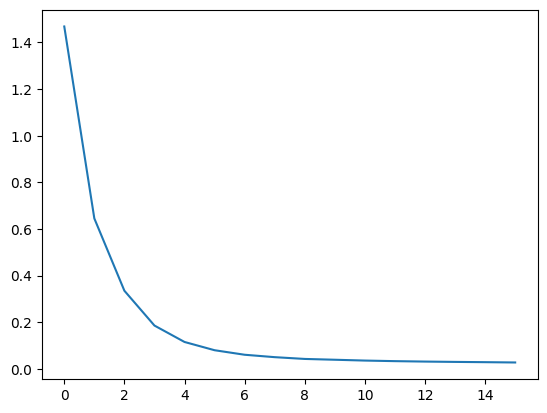

In [25]:
### Training Execution
train_model(
    dataloader=train_dataloader, 
    encoder=encoder, 
    decoder=decoder, 
    epochs=80, 
    print_every=5, 
    plot_every=5
)

In [26]:
### Evaluation
encoder.eval()
decoder.eval()
evaluate_randomly(encoder, decoder, n=10)

> je commence a me sentir desespere .
= i m starting to feel desperate .
< i m starting to feel desperate . <EOS>

> nous sommes juste comme des freres .
= we re just like brothers .
< we re just like brothers . <EOS>

> vous etes tres brave .
= you re very brave .
< you re very brave . <EOS>

> nous n en sommes pas encore surs .
= we re not sure yet .
< we re not sure yet . <EOS>

> je suis etudiant .
= i m a student .
< i m a student . <EOS>

> vous n etes pas ma mere .
= you re not my mother .
< you re not my mother . <EOS>

> il est fort grand .
= he is very tall .
< he is very tall as he is . <EOS>

> je suis evidemment tres decue .
= i m obviously very disappointed .
< i m obviously very disappointed . <EOS>

> ils sont encore des enfants .
= they are still children .
< they are still children . <EOS>

> ils sont partis .
= they re gone .
< they re gone at war . <EOS>



input = il n est pas aussi grand que son pere
output = he s not tall as his father . <EOS>


C:\Users\Anshu Singh\AppData\Local\Temp\ipykernel_2612\1279437905.py:146: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([''] + input_sentence.split(' ') + ['<EOS>'], rotation=90)
C:\Users\Anshu Singh\AppData\Local\Temp\ipykernel_2612\1279437905.py:147: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([''] + output_words)


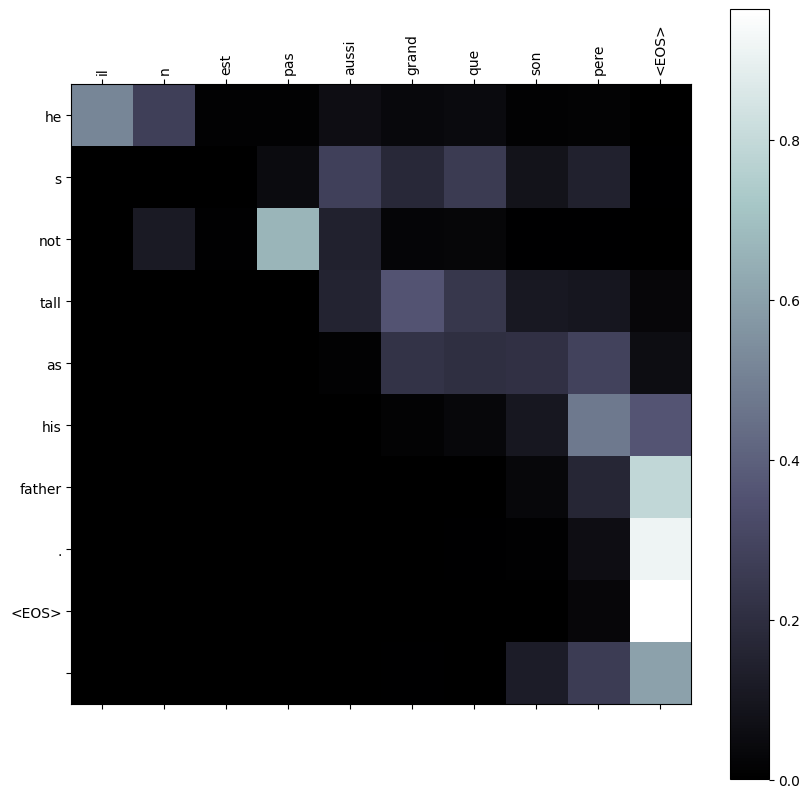

input = je suis trop fatigue pour conduire
output = i m too tired to drive . <EOS>


C:\Users\Anshu Singh\AppData\Local\Temp\ipykernel_2612\1279437905.py:146: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([''] + input_sentence.split(' ') + ['<EOS>'], rotation=90)
C:\Users\Anshu Singh\AppData\Local\Temp\ipykernel_2612\1279437905.py:147: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([''] + output_words)


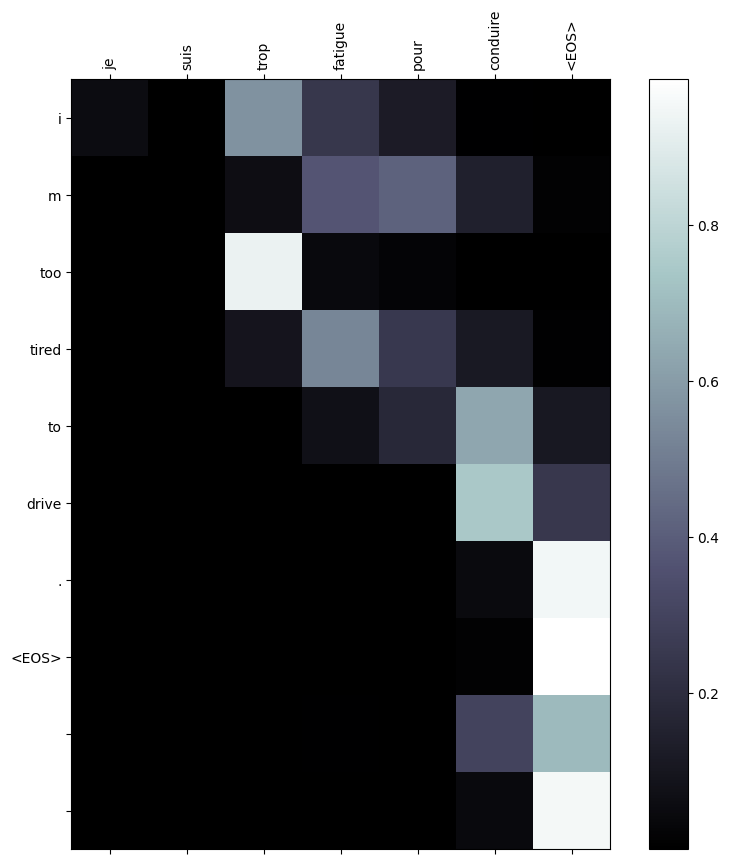

input = je suis desole si c est une question idiote
output = i m sorry if i m a child . <EOS>


C:\Users\Anshu Singh\AppData\Local\Temp\ipykernel_2612\1279437905.py:146: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([''] + input_sentence.split(' ') + ['<EOS>'], rotation=90)
C:\Users\Anshu Singh\AppData\Local\Temp\ipykernel_2612\1279437905.py:147: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([''] + output_words)


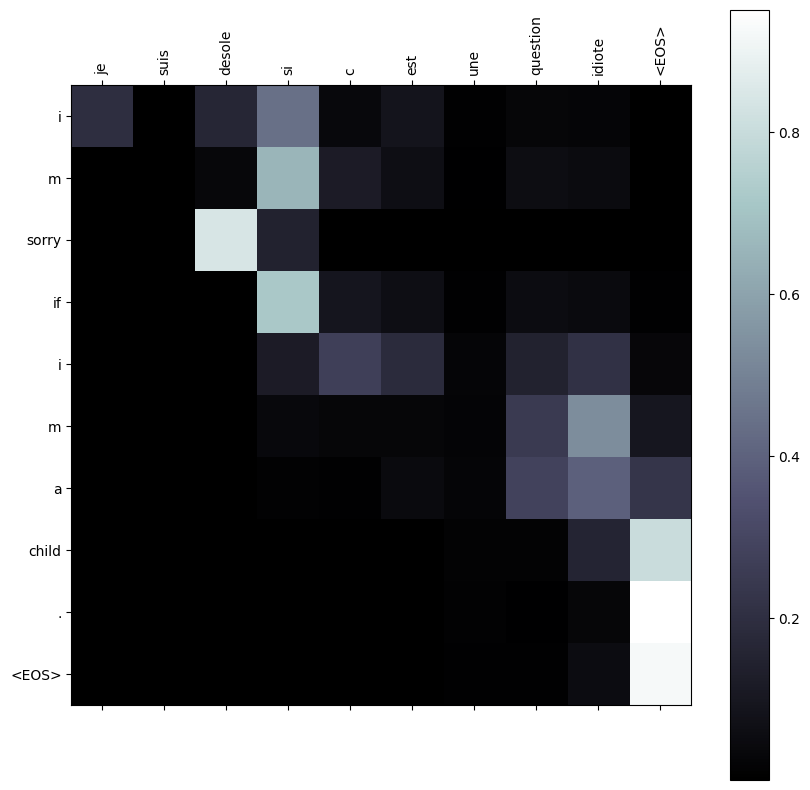

input = je suis reellement fiere de vous
output = i m really proud of you . <EOS>


C:\Users\Anshu Singh\AppData\Local\Temp\ipykernel_2612\1279437905.py:146: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([''] + input_sentence.split(' ') + ['<EOS>'], rotation=90)
C:\Users\Anshu Singh\AppData\Local\Temp\ipykernel_2612\1279437905.py:147: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([''] + output_words)


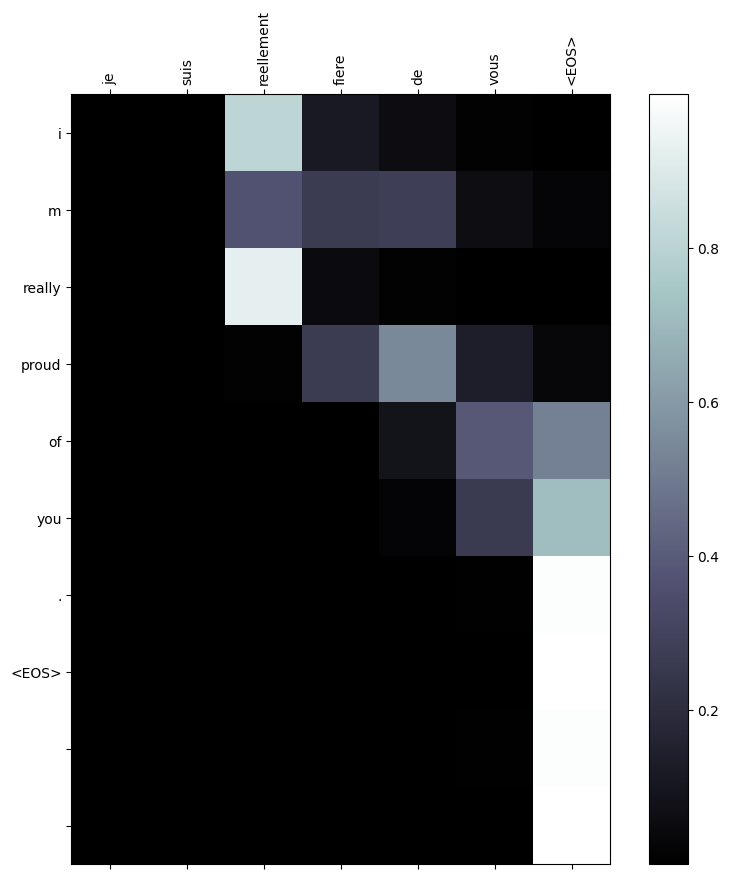

In [31]:
### Specific Evaluation and Attention Visualization

# Example 1: Comparison
evaluate_and_show_attention('il n est pas aussi grand que son pere')

# Example 2: Adjective/Condition
evaluate_and_show_attention('je suis trop fatigue pour conduire')

# Example 3: Complex Sentence
evaluate_and_show_attention('je suis desole si c est une question idiote')

# Example 4: Emotional Sentiment
evaluate_and_show_attention('je suis reellement fiere de vous')